# Importing Libraries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dropout,
    GlobalAveragePooling2D,
    Dense
)

from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow Version:", tf.__version__)

2026-05-13 05:12:01.248841: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778649121.466940     105 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778649121.537095     105 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778649122.143674     105 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778649122.143713     105 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778649122.143716     105 computation_placer.cc:177] computation placer alr

TensorFlow Version: 2.19.0


# Checking Dataset Path

In [2]:
import os

# Show folders inside Kaggle input
print(os.listdir('/kaggle/input'))

['datasets']


# Finding Tomato Dataset Path

In [3]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    if len(dirs) > 0:
        print(root)
        print(dirs[:5])
        print("-"*50)

/kaggle/input
['datasets']
--------------------------------------------------
/kaggle/input/datasets
['emmarex']
--------------------------------------------------
/kaggle/input/datasets/emmarex
['plantdisease']
--------------------------------------------------
/kaggle/input/datasets/emmarex/plantdisease
['PlantVillage', 'plantvillage']
--------------------------------------------------
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage
['Pepper__bell___Bacterial_spot', 'Potato___healthy', 'Tomato_Leaf_Mold', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_Bacterial_spot']
--------------------------------------------------
/kaggle/input/datasets/emmarex/plantdisease/plantvillage
['PlantVillage']
--------------------------------------------------
/kaggle/input/datasets/emmarex/plantdisease/plantvillage/PlantVillage
['Pepper__bell___Bacterial_spot', 'Potato___healthy', 'Tomato_Leaf_Mold', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_Bacterial_spot']
--------------------------

# Tomato Dataset Generators

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Tomato dataset path
dataset_path = "/kaggle/input/datasets/emmarex/plantdisease/PlantVillage"

# Data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=30,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2]
)

# Training generator
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    classes=[
        'Tomato_Bacterial_spot',
        'Tomato_Early_blight',
        'Tomato_Late_blight',
        'Tomato_Leaf_Mold',
        'Tomato_Septoria_leaf_spot',
        'Tomato_Spider_mites_Two_spotted_spider_mite',
        'Tomato__Target_Spot',
        'Tomato__Tomato_YellowLeaf__Curl_Virus',
        'Tomato__Tomato_mosaic_virus',
        'Tomato_healthy'
    ],
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# Validation generator
val_generator = train_datagen.flow_from_directory(
    dataset_path,
    classes=[
        'Tomato_Bacterial_spot',
        'Tomato_Early_blight',
        'Tomato_Late_blight',
        'Tomato_Leaf_Mold',
        'Tomato_Septoria_leaf_spot',
        'Tomato_Spider_mites_Two_spotted_spider_mite',
        'Tomato__Target_Spot',
        'Tomato__Tomato_YellowLeaf__Curl_Virus',
        'Tomato__Tomato_mosaic_virus',
        'Tomato_healthy'
    ],
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# Class names
class_names = list(train_generator.class_indices.keys())

print("Number of classes:", len(class_names))
print(class_names)

Found 12813 images belonging to 10 classes.
Found 3198 images belonging to 10 classes.
Number of classes: 10
['Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


# Build Custom CNN

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dropout,
    GlobalAveragePooling2D,
    Dense
)

# Custom CNN Model
model = Sequential([

    Input(shape=(224,224,3)),

    # Block 1
    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Block 2
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Block 3
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Block 4
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Global Average Pooling
    GlobalAveragePooling2D(),

    # Dense Layer
    Dense(256, activation='relu'),
    Dropout(0.5),

    # Output Layer
    Dense(10, activation='softmax')
])

# Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Summary
model.summary()

I0000 00:00:1778649216.619573     105 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 458,698 (1.75 MB)

 Trainable params: 457,738 (1.75 MB)

 Non-trainable params: 960 (3.75 KB)

# Train the CNN Model

In [6]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1778649222.820720     182 service.cc:152] XLA service 0x7cbb40108a00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778649222.820753     182 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778649223.572743     182 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/401 ━━━━━━━━━━━━━━━━━━━━ 1:09:22 10s/step - accuracy: 0.0625 - loss: 3.1344

I0000 00:00:1778649229.656316     182 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


401/401 ━━━━━━━━━━━━━━━━━━━━ 305s 737ms/step - accuracy: 0.5990 - loss: 1.1811 - val_accuracy: 0.2292 - val_loss: 5.4987
Epoch 2/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 204s 508ms/step - accuracy: 0.8000 - loss: 0.5785 - val_accuracy: 0.7067 - val_loss: 0.9538
Epoch 3/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 205s 512ms/step - accuracy: 0.8651 - loss: 0.4006 - val_accuracy: 0.7886 - val_loss: 0.5939
Epoch 4/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 203s 505ms/step - accuracy: 0.8875 - loss: 0.3268 - val_accuracy: 0.8799 - val_loss: 0.3335
Epoch 5/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 204s 508ms/step - accuracy: 0.9008 - loss: 0.2731 - val_accuracy: 0.8540 - val_loss: 0.4428
Epoch 6/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 202s 503ms/step - accuracy: 0.9209 - loss: 0.2396 - val_accuracy: 0.7289 - val_loss: 0.9518
Epoch 7/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 204s 510ms/step - accuracy: 0.9320 - loss: 0.2016 - val_accuracy: 0.7827 - val_loss: 0.8208
Epoch 8/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 205s 512ms/step - accuracy: 0.9412 - loss: 0.17

# Plot Accuracy & Loss Curves

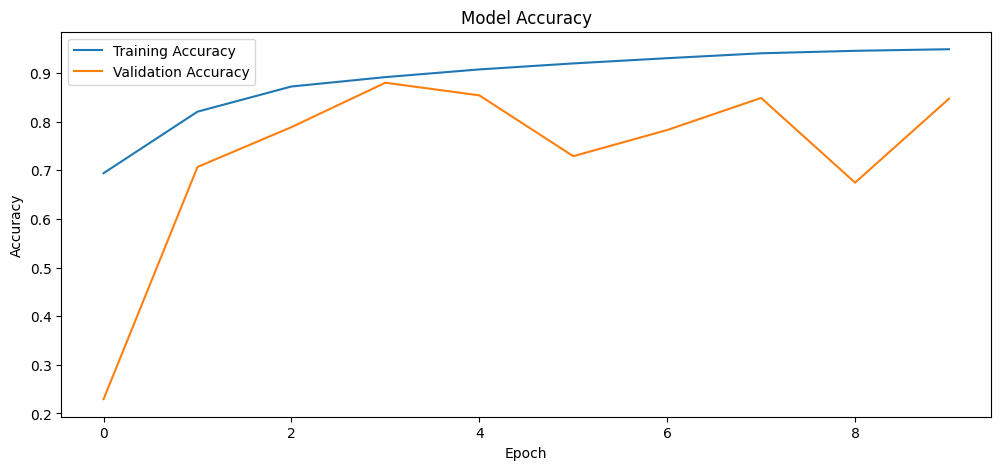

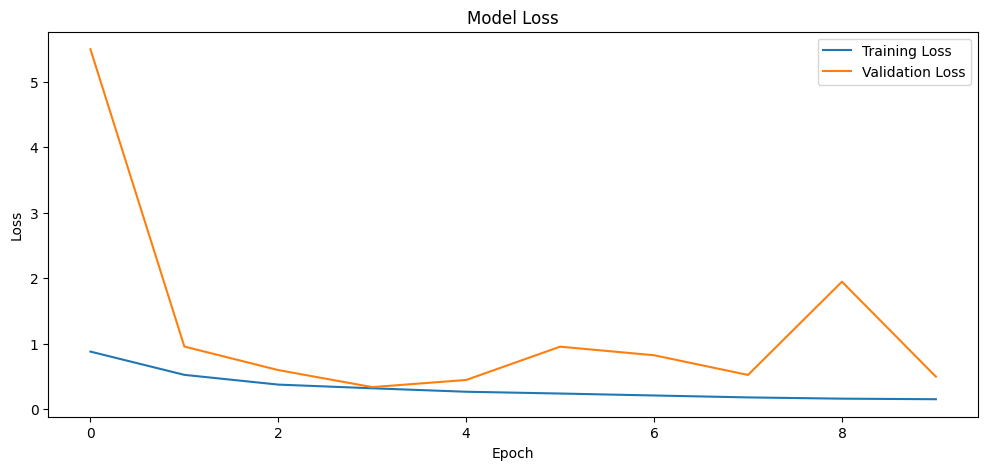

In [7]:
# Accuracy Plot
plt.figure(figsize=(12,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


# Loss Plot
plt.figure(figsize=(12,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Generate Predictions

In [8]:
# Predict validation data
pred_probs = model.predict(val_generator)

# Predicted class indices
pred_classes = np.argmax(pred_probs, axis=1)

# True class indices
true_classes = val_generator.classes

100/100 ━━━━━━━━━━━━━━━━━━━━ 43s 422ms/step


# Classification Report + Normalized Confusion Matrix

                                             precision    recall  f1-score   support

                      Tomato_Bacterial_spot       0.98      0.89      0.93       425
                        Tomato_Early_blight       0.87      0.81      0.84       200
                         Tomato_Late_blight       0.77      0.89      0.82       381
                           Tomato_Leaf_Mold       0.93      0.56      0.70       190
                  Tomato_Septoria_leaf_spot       0.85      0.98      0.91       354
Tomato_Spider_mites_Two_spotted_spider_mite       0.67      0.91      0.77       335
                        Tomato__Target_Spot       0.90      0.85      0.88       280
      Tomato__Tomato_YellowLeaf__Curl_Virus       1.00      0.70      0.82       641
                Tomato__Tomato_mosaic_virus       0.89      1.00      0.94        74
                             Tomato_healthy       0.78      1.00      0.88       318

                                   accuracy                    

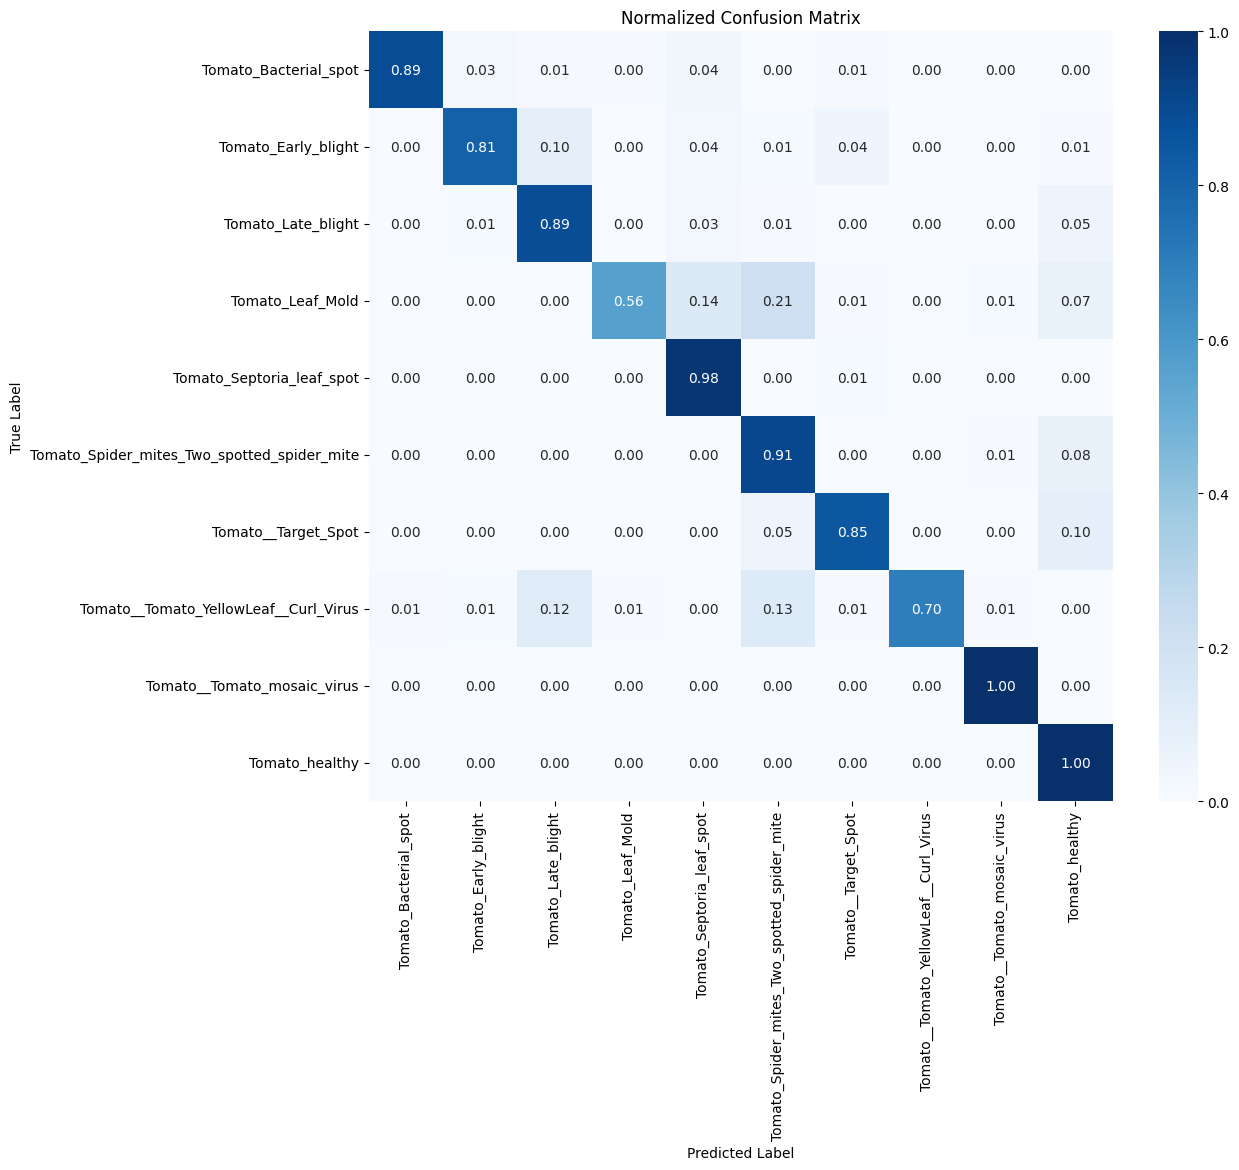

In [9]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Classification Report
report = classification_report(
    true_classes,
    pred_classes,
    target_names=class_names
)

print(report)

# Confusion Matrix
cm = confusion_matrix(true_classes, pred_classes)

# Normalize confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot
plt.figure(figsize=(12,10))

sns.heatmap(
    cm_normalized,
    annot=True,
    cmap='Blues',
    fmt='.2f',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.show()

# Save Custom CNN Model

In [10]:
# Save model
model.save("tomato_custom_cnn_model.h5")

print("Custom CNN model saved successfully!")

Custom CNN model saved successfully!


# Load MobileNetV2 Base Model

In [11]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

# Load pretrained MobileNetV2
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze base model layers
base_model.trainable = False

print("MobileNetV2 base model loaded!")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
MobileNetV2 base model loaded!


# Build MobileNetV2 Transfer Learning Model

In [12]:
# Build Transfer Learning Model
transfer_model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(10, activation='softmax')
])

# Compile model
transfer_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
transfer_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,490 (9.87 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

# Train MobileNetV2 Model

In [13]:
transfer_history = transfer_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
401/401 ━━━━━━━━━━━━━━━━━━━━ 237s 562ms/step - accuracy: 0.5778 - loss: 1.2407 - val_accuracy: 0.8105 - val_loss: 0.5301
Epoch 2/5
401/401 ━━━━━━━━━━━━━━━━━━━━ 208s 518ms/step - accuracy: 0.7756 - loss: 0.6424 - val_accuracy: 0.8590 - val_loss: 0.4327
Epoch 3/5
401/401 ━━━━━━━━━━━━━━━━━━━━ 208s 518ms/step - accuracy: 0.8186 - loss: 0.5378 - val_accuracy: 0.8668 - val_loss: 0.3847
Epoch 4/5
401/401 ━━━━━━━━━━━━━━━━━━━━ 211s 525ms/step - accuracy: 0.8290 - loss: 0.5065 - val_accuracy: 0.8630 - val_loss: 0.3991
Epoch 5/5
401/401 ━━━━━━━━━━━━━━━━━━━━ 208s 519ms/step - accuracy: 0.8372 - loss: 0.4694 - val_accuracy: 0.8662 - val_loss: 0.3705


# Evaluate MobileNetV2

In [14]:
# Predict validation data
transfer_pred_probs = transfer_model.predict(val_generator)

# Predicted classes
transfer_pred_classes = np.argmax(transfer_pred_probs, axis=1)

# Classification Report
transfer_report = classification_report(
    true_classes,
    transfer_pred_classes,
    target_names=class_names
)

print(transfer_report)

100/100 ━━━━━━━━━━━━━━━━━━━━ 50s 460ms/step
                                             precision    recall  f1-score   support

                      Tomato_Bacterial_spot       0.91      0.92      0.91       425
                        Tomato_Early_blight       0.85      0.60      0.70       200
                         Tomato_Late_blight       0.83      0.94      0.89       381
                           Tomato_Leaf_Mold       0.97      0.74      0.84       190
                  Tomato_Septoria_leaf_spot       0.85      0.86      0.85       354
Tomato_Spider_mites_Two_spotted_spider_mite       0.88      0.77      0.82       335
                        Tomato__Target_Spot       0.73      0.80      0.76       280
      Tomato__Tomato_YellowLeaf__Curl_Virus       0.97      0.97      0.97       641
                Tomato__Tomato_mosaic_virus       0.87      0.99      0.92        74
                             Tomato_healthy       0.86      0.98      0.91       318

                   

# Save MobileNetV2 Model

In [15]:
transfer_model.save("tomato_mobilenetv2_model.h5")

print("MobileNetV2 model saved successfully!")

MobileNetV2 model saved successfully!


# Create Disease Treatment Dictionary

In [16]:
# Treatment recommendations
treatment_dict = {

    "Tomato_Bacterial_spot":
    "Remove infected leaves and apply copper-based bactericides.",

    "Tomato_Early_blight":
    "Use fungicides and avoid overhead irrigation.",

    "Tomato_Late_blight":
    "Remove infected plants immediately and apply protective fungicides.",

    "Tomato_Leaf_Mold":
    "Improve air circulation and reduce humidity levels.",

    "Tomato_Septoria_leaf_spot":
    "Prune infected leaves and apply appropriate fungicide spray.",

    "Tomato_Spider_mites_Two_spotted_spider_mite":
    "Use insecticidal soap or neem oil to control mites.",

    "Tomato__Target_Spot":
    "Remove affected leaves and apply fungicide treatment.",

    "Tomato__Tomato_YellowLeaf__Curl_Virus":
    "Control whiteflies and remove infected plants.",

    "Tomato__Tomato_mosaic_virus":
    "Disinfect tools and remove infected plants to prevent spread.",

    "Tomato_healthy":
    "The plant appears healthy. Continue proper care and monitoring."
}

print("Treatment dictionary created successfully!")

Treatment dictionary created successfully!


# Create Streamlit App File

In [17]:
streamlit_code = '''
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image

# Load model
model = tf.keras.models.load_model("tomato_mobilenetv2_model.h5")

# Class names
class_names = [
    'Tomato_Bacterial_spot',
    'Tomato_Early_blight',
    'Tomato_Late_blight',
    'Tomato_Leaf_Mold',
    'Tomato_Septoria_leaf_spot',
    'Tomato_Spider_mites_Two_spotted_spider_mite',
    'Tomato__Target_Spot',
    'Tomato__Tomato_YellowLeaf__Curl_Virus',
    'Tomato__Tomato_mosaic_virus',
    'Tomato_healthy'
]

# Treatment recommendations
treatment_dict = {

    "Tomato_Bacterial_spot":
    "Remove infected leaves and apply copper-based bactericides.",

    "Tomato_Early_blight":
    "Use fungicides and avoid overhead irrigation.",

    "Tomato_Late_blight":
    "Remove infected plants immediately and apply protective fungicides.",

    "Tomato_Leaf_Mold":
    "Improve air circulation and reduce humidity levels.",

    "Tomato_Septoria_leaf_spot":
    "Prune infected leaves and apply appropriate fungicide spray.",

    "Tomato_Spider_mites_Two_spotted_spider_mite":
    "Use insecticidal soap or neem oil to control mites.",

    "Tomato__Target_Spot":
    "Remove affected leaves and apply fungicide treatment.",

    "Tomato__Tomato_YellowLeaf__Curl_Virus":
    "Control whiteflies and remove infected plants.",

    "Tomato__Tomato_mosaic_virus":
    "Disinfect tools and remove infected plants to prevent spread.",

    "Tomato_healthy":
    "The plant appears healthy. Continue proper care and monitoring."
}

# Streamlit page config
st.set_page_config(page_title="Tomato Leaf Disease Classifier")

st.title("🍅 Tomato Leaf Disease Classification")

st.write(
    "Upload a tomato leaf image to predict the disease "
    "and receive treatment advice."
)

# File uploader
uploaded_file = st.file_uploader(
    "Upload a Tomato Leaf Image",
    type=["jpg", "jpeg", "png"]
)

if uploaded_file is not None:

    # Open image
    image = Image.open(uploaded_file)

    # Display image
    st.image(image, caption="Uploaded Image", use_container_width=True)

    # Preprocess image
    img = image.resize((224,224))
    img_array = np.array(img) / 255.0

    # Ensure RGB
    if img_array.shape[-1] == 4:
        img_array = img_array[:, :, :3]

    img_array = np.expand_dims(img_array, axis=0)

    # Prediction
    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions)]

    confidence = np.max(predictions) * 100

    # Output
    st.subheader("Prediction Result")

    st.success(f"Disease: {predicted_class}")

    st.info(f"Confidence Score: {confidence:.2f}%")

    # Treatment
    st.subheader("Treatment Recommendation")

    st.write(treatment_dict[predicted_class])

    # Probability chart
    st.subheader("Prediction Probabilities")

    prob_dict = {
        class_names[i]: float(predictions[0][i])
        for i in range(len(class_names))
    }

    st.bar_chart(prob_dict)

# Disclaimer
st.warning(
    "Disclaimer: This prediction system is for educational "
    "and research purposes only. Always consult agricultural "
    "experts before taking large-scale farming decisions."
)
'''

# Save app.py
with open("app.py", "w") as f:
    f.write(streamlit_code)

print("Streamlit app.py file created successfully!")

Streamlit app.py file created successfully!


# Create .keras Model

In [19]:
# Save model in modern Keras format
transfer_model.save("tomato_mobilenetv2_model.keras")

print("Keras model saved successfully!")

Keras model saved successfully!


# Create requirements.txt

In [20]:
requirements = """
streamlit
tensorflow
numpy
pillow
"""

with open("requirements.txt", "w") as f:
    f.write(requirements)

print("requirements.txt created successfully!")

requirements.txt created successfully!


#  Create README.md

In [23]:
readme_text = r"""
# Tomato Leaf Disease Classification

## Project Overview
This project is a deep learning-based tomato leaf disease classification system developed using TensorFlow and Keras.

The system classifies 10 different tomato leaf conditions, including healthy leaves and multiple diseases, from uploaded leaf images.

A Streamlit web application is included for real-time disease prediction and treatment recommendation.

---

## Features
- Tomato leaf disease classification
- Custom CNN model
- Transfer Learning using MobileNetV2
- Image upload interface
- Confidence score prediction
- Treatment recommendation system
- Visualization of prediction probabilities

---

## Dataset
PlantVillage Dataset (Tomato Classes)

Dataset Source:
https://www.kaggle.com/datasets/emmarex/plantdisease

---

## Technologies Used
- Python
- TensorFlow / Keras
- Streamlit
- NumPy
- Matplotlib
- Seaborn

---

## Model Performance

### Custom CNN
- Validation Accuracy: ~74%

### MobileNetV2
- Validation Accuracy: ~88%

---

## Project Structure

- app.py
- requirements.txt
- tomato_mobilenetv2_model.keras
- Tomato_Leaf_Disease_Classification.ipynb

---

## Run Locally

pip install -r requirements.txt

streamlit run app.py

---

## Disclaimer

This system is developed for educational and research purposes only.

Always consult agricultural experts before making large-scale farming decisions.
"""

with open("README.md", "w") as f:
    f.write(readme_text)

print("README.md created successfully!")

README.md created successfully!
